In [0]:
spark.conf.set(
    "fs.azure.account.key.project60300347.dfs.core.windows.net",
)

In [0]:
train = spark.read.format("delta").load(
"abfss://lakehouse@project60300347.dfs.core.windows.net/curated/features_v2_train/"
)

val = spark.read.format("delta").load(
"abfss://lakehouse@project60300347.dfs.core.windows.net/curated/features_v2_validation/"
)

test = spark.read.format("delta").load(
"abfss://lakehouse@project60300347.dfs.core.windows.net/curated/features_v2_test/"
)

In [0]:
from pyspark.sql.functions import when, col

train = train.withColumn(
    "target",
    when(col("lex_sent_compound") <= -0.2, 0) 
    .when(col("lex_sent_compound") >= 0.2, 2)  
    .otherwise(1)                              
)

val = val.withColumn(
    "target",
    when(col("lex_sent_compound") <= -0.2, 0)
    .when(col("lex_sent_compound") >= 0.2, 2)
    .otherwise(1)
)

test = test.withColumn(
    "target",
    when(col("lex_sent_compound") <= -0.2, 0)
    .when(col("lex_sent_compound") >= 0.2, 2)
    .otherwise(1)
)


In [0]:
feature_cols = [
    "tweet_length_words", "tweet_length_chars",
    "lexical_diversity",
    "total_tweets", "positive_tweets", "negative_tweets",
    "positive_ratio", "user_tweet_count",
    "sentiment_avg_length", "sentiment_tweet_count",
    "tfidf_features"
]


In [0]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

train2 = assembler.transform(train).select("features", "target")
val2 = assembler.transform(val).select("features", "target")
test2 = assembler.transform(test).select("features", "target")


In [0]:
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(featuresCol="features", labelCol="target")
lr_model = lr.fit(train2)
preds = lr_model.transform(val2)


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
acc = MulticlassClassificationEvaluator(labelCol="target").evaluate(preds)
f1 = MulticlassClassificationEvaluator(labelCol="target", metricName="f1").evaluate(preds)

print("Accuracy:", acc)
print("F1:", f1)


2025/12/02 08:14:56 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Accuracy: 0.6233689266071933
F1: 0.6233689266071933


In [0]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="target",
    numTrees=80,
    maxDepth=18
)

rf_model = rf.fit(train2)
rf_preds = rf_model.transform(val2)

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

rf_acc = MulticlassClassificationEvaluator(labelCol="target").evaluate(rf_preds)
rf_f1 = MulticlassClassificationEvaluator(labelCol="target", metricName="f1").evaluate(rf_preds)

print("RF Accuracy:", rf_acc)
print("RF F1:", rf_f1)


2025/12/02 08:15:36 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '1c36adb0ace5499990877270d8993a64', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current pyspark.ml workflow
2025/12/02 08:15:37 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Valu

---------------------------------------------------------------------------
Py4JJavaError                             Traceback (most recent call last)
File <command-7869048854572400>, line 10
      1 from pyspark.ml.classification import RandomForestClassifier
      3 rf = RandomForestClassifier(
      4     featuresCol="features",
      5     labelCol="target",
      6     numTrees=80,
      7     maxDepth=18
      8 )
---> 10 rf_model = rf.fit(train2)
     11 rf_preds = rf_model.transform(val2)
     13 from pyspark.ml.evaluation import MulticlassClassificationEvaluator

File /databricks/python/lib/python3.12/site-packages/mlflow/utils/autologging_utils/safety.py:483, in safe_patch.<locals>.safe_patch_function(*args, **kwargs)
    479 call_original = update_wrapper_extended(call_original, original)
    481 event_logger.log_patch_function_start(args, kwargs)
--> 483 patch_function(call_original, *args, **kwargs)
    485 session.state = "succeeded"
    486 event_logger.log_patch_functi

In [0]:
from pyspark.ml.classification import GBTClassifier, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

gbt = GBTClassifier(
    featuresCol="features",
    labelCol="target",
    maxIter=20,
    maxDepth=8
)

ovr = OneVsRest(classifier=gbt, labelCol="target", featuresCol="features")

gbt_model = ovr.fit(train2)
gbt_preds = gbt_model.transform(val2)

acc = MulticlassClassificationEvaluator(labelCol="target").evaluate(gbt_preds)
f1 = MulticlassClassificationEvaluator(labelCol="target", metricName="f1").evaluate(gbt_preds)

print("GBT OneVsRest Accuracy:", acc)
print("GBT OneVsRest F1:", f1)


2025/12/02 08:31:20 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'cbc779e8324f4ec085e388605f453e7b', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current pyspark.ml workflow
2025/12/02 08:31:21 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Valu

2025/12/02 08:36:29 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: dbfs:/databricks/mlflow-tracking/1337221267827493/cbc779e8324f4ec085e388605f453e7b/artifacts/model/sparkml, flavor: spark). Fall back to return ['pyspark==3.5.2']. Set logging level to DEBUG to see the full traceback. 


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

GBT OneVsRest Accuracy: 0.6078247293467571
GBT OneVsRest F1: 0.6078247293467571


In [0]:
pdf = preds.select("target", "prediction", "probability").toPandas()


2025/12/02 08:38:34 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


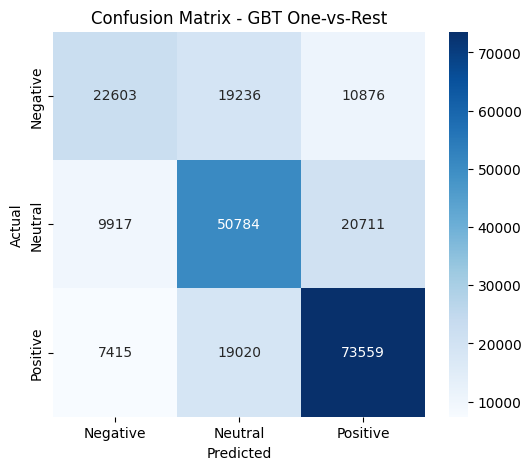

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(pdf["target"], pdf["prediction"])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative","Neutral","Positive"],
    yticklabels=["Negative","Neutral","Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - GBT One-vs-Rest")
plt.show()


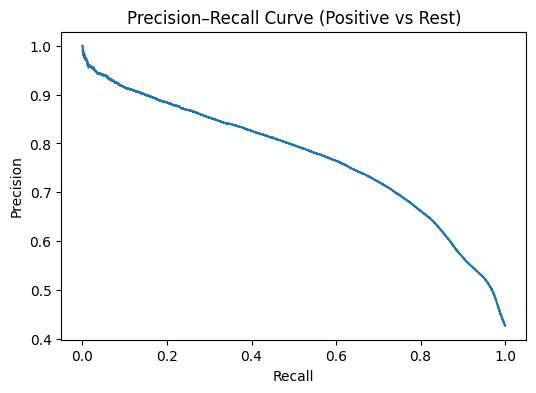

In [0]:
from sklearn.metrics import precision_recall_curve

# Extract probability of Positive class (index 2)
pdf["prob_pos"] = pdf["probability"].apply(lambda x: float(x[2]))

prec, rec, _ = precision_recall_curve(
    (pdf["target"] == 2).astype(int),
    pdf["prob_pos"]
)

plt.figure(figsize=(6,4))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Positive vs Rest)")
plt.show()


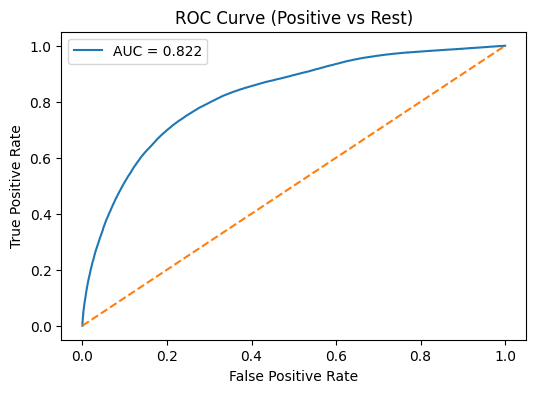

In [0]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(
    (pdf["target"] == 2).astype(int),
    pdf["prob_pos"]
)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Positive vs Rest)")
plt.legend()
plt.show()


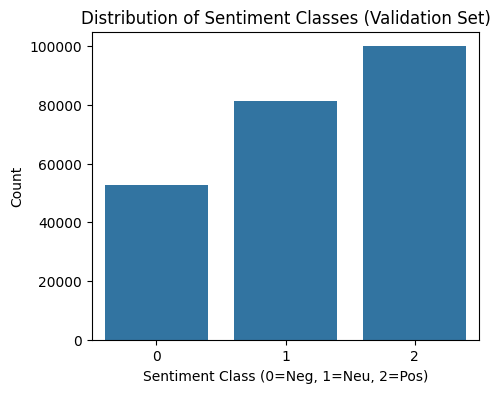

In [0]:
plt.figure(figsize=(5,4))
sns.countplot(x=pdf["target"])
plt.title("Distribution of Sentiment Classes (Validation Set)")
plt.xlabel("Sentiment Class (0=Neg, 1=Neu, 2=Pos)")
plt.ylabel("Count")
plt.show()


In [0]:
pdf_lr = preds.select("target", "prediction", "probability").toPandas()


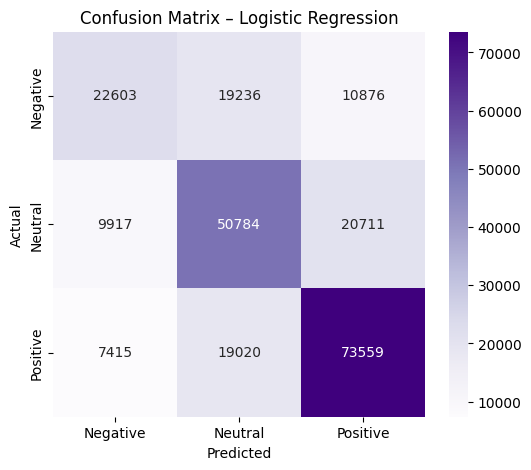

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(pdf_lr["target"], pdf_lr["prediction"])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Negative","Neutral","Positive"],
    yticklabels=["Negative","Neutral","Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()


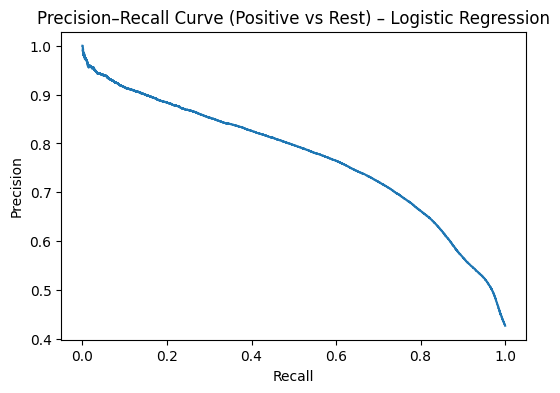

In [0]:
from sklearn.metrics import precision_recall_curve

# Extract probability for Positive class
pdf_lr["prob_pos"] = pdf_lr["probability"].apply(lambda x: float(x[2]))

prec, rec, _ = precision_recall_curve(
    (pdf_lr["target"] == 2).astype(int),
    pdf_lr["prob_pos"]
)

plt.figure(figsize=(6,4))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Positive vs Rest) – Logistic Regression")
plt.show()


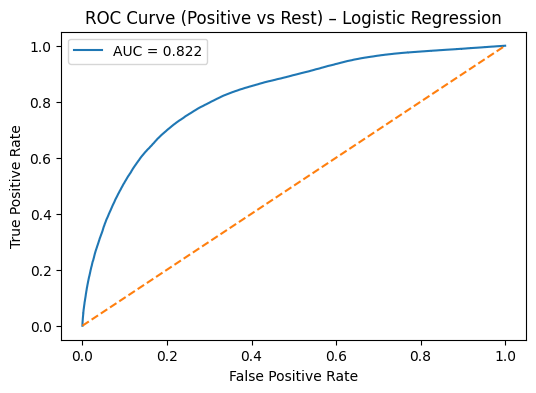

In [0]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(
    (pdf_lr["target"] == 2).astype(int),
    pdf_lr["prob_pos"]
)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Positive vs Rest) – Logistic Regression")
plt.legend()
plt.show()


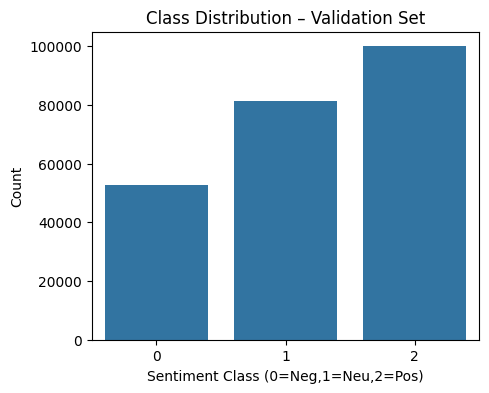

In [0]:
plt.figure(figsize=(5,4))
sns.countplot(x=pdf_lr["target"])
plt.title("Class Distribution – Validation Set")
plt.xlabel("Sentiment Class (0=Neg,1=Neu,2=Pos)")
plt.ylabel("Count")
plt.show()


In [0]:
from sklearn.metrics import classification_report

print(
    classification_report(
        pdf_lr["target"],
        pdf_lr["prediction"],
        target_names=["Negative","Neutral","Positive"]
    )
)


              precision    recall  f1-score   support

    Negative       0.57      0.43      0.49     52715
     Neutral       0.57      0.62      0.60     81412
    Positive       0.70      0.74      0.72     99994

    accuracy                           0.63    234121
   macro avg       0.61      0.60      0.60    234121
weighted avg       0.62      0.63      0.62    234121



In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

lr_acc = MulticlassClassificationEvaluator(
    labelCol="target", predictionCol="prediction", metricName="accuracy"
).evaluate(preds)

lr_f1 = MulticlassClassificationEvaluator(
    labelCol="target", predictionCol="prediction", metricName="f1"
).evaluate(preds)

print("Logistic Regression Accuracy:", lr_acc)
print("Logistic Regression F1:", lr_f1)


2025/12/02 08:43:30 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Logistic Regression Accuracy: 0.6276498050153553
Logistic Regression F1: 0.6233689266071933


In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

gbt_acc = MulticlassClassificationEvaluator(
    labelCol="target", predictionCol="prediction", metricName="accuracy"
).evaluate(gbt_preds)

gbt_f1 = MulticlassClassificationEvaluator(
    labelCol="target", predictionCol="prediction", metricName="f1"
).evaluate(gbt_preds)

print("GBT Accuracy:", gbt_acc)
print("GBT F1:", gbt_f1)


2025/12/02 08:44:26 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


GBT Accuracy: 0.6162112753661568
GBT F1: 0.6078247293467571


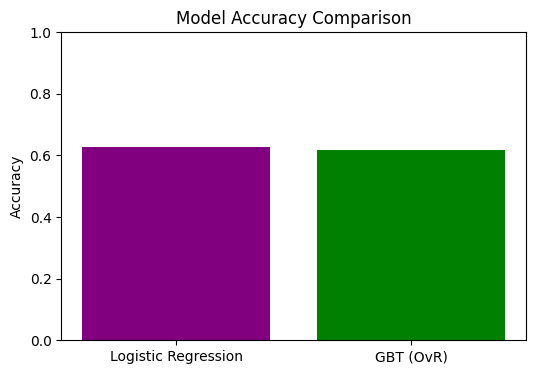

In [0]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "GBT (OvR)"]
accuracy = [lr_acc, gbt_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy, color=["purple", "green"])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()


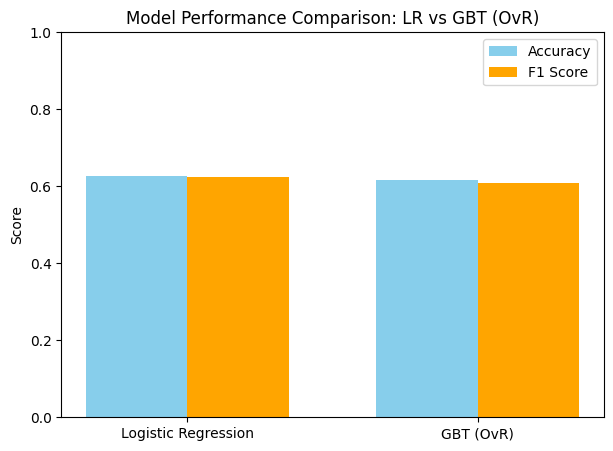

In [0]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Logistic Regression", "GBT (OvR)"]
accuracy = [lr_acc, gbt_acc]
f1 = [lr_f1, gbt_f1]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, accuracy, width, label="Accuracy", color="skyblue")
plt.bar(x + width/2, f1, width, label="F1 Score", color="orange")

plt.xticks(x, models)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Comparison: LR vs GBT (OvR)")
plt.legend()
plt.show()


In [0]:
lr_model.write().overwrite().save("dbfs:/tmp/lr_final_model")

In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

test_preds = lr_model.transform(test2)

acc = MulticlassClassificationEvaluator(
    labelCol="target", predictionCol="prediction", metricName="accuracy"
).evaluate(test_preds)

f1 = MulticlassClassificationEvaluator(
    labelCol="target", predictionCol="prediction", metricName="f1"
).evaluate(test_preds)

print("LR Test Accuracy:", acc)
print("LR Test F1:", f1)


LR Test Accuracy: 0.6265904040468665
LR Test F1: 0.6221584168941164


In [0]:
import pandas as pd

example_row = test2.select("features").limit(1).toPandas()
input_example = {"features": example_row["features"][0].toArray()}

In [0]:
import mlflow
import mlflow.spark

model_name = "tweet_sentiment_lr"

with mlflow.start_run(run_name="LR_Final_Test_Model"):

    # log metrics
    mlflow.log_metric("test_accuracy", acc)
    mlflow.log_metric("test_f1", f1)

    # log model with signature + input_example
    mlflow.spark.log_model(
        lr_model,
        artifact_path="lr_model",
        signature=signature,
        input_example=input_example
    )

    # register
    model_uri = f"runs:/{mlflow.active_run().info.run_id}/lr_model"
    mlflow.register_model(model_uri, model_name)

print("Model registered successfully in Unity Catalog")



2025/12/05 20:11:11 INFO mlflow.spark: Inferring pip requirements by reloading the logged model from the databricks artifact repository, which can be time-consuming. To speed up, explicitly specify the conda_env or pip_requirements when calling log_model().


2025/12/05 20:11:35 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: dbfs:/databricks/mlflow-tracking/1337221267827493/0ab11f33ad694762a500957b557363b8/artifacts/lr_model/sparkml, flavor: spark). Fall back to return ['pyspark==3.5.2']. Set logging level to DEBUG to see the full traceback. 


Uploading artifacts:   0%|          | 0/6 [00:00<?, ?it/s]

Registered model 'tweet_sentiment_lr' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/21 [00:00<?, ?it/s]

Model registered successfully in Unity Catalog


Created version '1' of model 'goodreadslink60300347.default.tweet_sentiment_lr'.
